In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pickle
import json
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device : {device}")
print(f"PyTorch : {torch.__version__}")

 Device : cpu
PyTorch : 2.11.0+cpu


In [2]:
# Chargement du modèle NLP entraîné
with open("../ml_models/text/tfidf_logreg_classifier.pkl", "rb") as f:
    nlp_pipeline = pickle.load(f)

with open("../ml_models/text/label_mapping.json", "r") as f:
    label_mapping = json.load(f)

label_to_category = {int(k): v for k, v in label_mapping["label_to_category"].items()}

# Chargement des notes
df_notes = pd.read_csv("../data/synthetic/consultation_notes.csv")
df_patients = pd.read_csv("../data/synthetic/patients.csv")
df_vitals = pd.read_csv("../data/synthetic/vitals_history.csv")

# Extraction des probabilités comme embedding texte
# Le vecteur de probabilités [P(normal), P(cardio), P(metabolic), P(infectious)]
# est une représentation dense et informative de la note
text_probas = nlp_pipeline.predict_proba(df_notes["note"].values)
text_labels = nlp_pipeline.predict(df_notes["note"].values)

print(f" Embeddings texte générés")
print(f"Shape : {text_probas.shape}  → (n_notes, n_classes)")
print(f"\nExemple d'embedding texte pour une note cardio :")
cardio_idx = df_notes[df_notes["category"] == "cardio"].index[0]
print(f"Note : {df_notes.loc[cardio_idx, 'note'][:60]}...")
print(f"Probabilités : {dict(zip(label_to_category.values(), text_probas[cardio_idx].round(3)))}")

 Embeddings texte générés
Shape : (500, 4)  → (n_notes, n_classes)

Exemple d'embedding texte pour une note cardio :
Note : Oedème des membres inférieurs bilatéral. Essoufflement au mo...
Probabilités : {'normal': np.float64(0.043), 'cardio': np.float64(0.878), 'metabolic': np.float64(0.041), 'infectious': np.float64(0.038)}


In [3]:
def extract_vitals_features(df_vitals: pd.DataFrame, patient_id: str) -> np.ndarray:
    """
    Extrait un vecteur de features statistiques à partir de l'historique vitaux.
    Pour chaque paramètre : mean, std, min, max, dernière valeur, tendance (slope).
    
    Ce vecteur compact représente le profil temporel du patient.
    """
    VITAL_PARAMS = ["systolic_bp", "diastolic_bp", "heart_rate", "glucose", "weight"]
    patient_data = df_vitals[df_vitals["patient_id"] == patient_id].sort_values("day")

    features = []
    for param in VITAL_PARAMS:
        if param not in patient_data.columns or patient_data[param].isna().all():
            features.extend([0.0] * 6)
            continue

        values = patient_data[param].dropna().values
        if len(values) == 0:
            features.extend([0.0] * 6)
            continue

        mean_val = float(np.mean(values))
        std_val = float(np.std(values))
        min_val = float(np.min(values))
        max_val = float(np.max(values))
        last_val = float(values[-1])

        # Tendance linéaire (slope) sur les 14 derniers jours
        if len(values) >= 2:
            x = np.arange(len(values[-14:]))
            slope = float(np.polyfit(x, values[-14:], 1)[0])
        else:
            slope = 0.0

        features.extend([mean_val, std_val, min_val, max_val, last_val, slope])

    return np.array(features, dtype=np.float32)


# Génération des embeddings vitaux pour tous les patients disponibles
vitals_patients = df_vitals["patient_id"].unique()
vitals_embeddings = {}

for pid in vitals_patients:
    vitals_embeddings[pid] = extract_vitals_features(df_vitals, pid)

print(f" Embeddings vitaux générés pour {len(vitals_embeddings)} patients")
print(f"Dimension par patient : {len(list(vitals_embeddings.values())[0])} features")
print(f"(5 paramètres × 6 statistiques = 30 features)")

 Embeddings vitaux générés pour 20 patients
Dimension par patient : 30 features
(5 paramètres × 6 statistiques = 30 features)


In [4]:
def build_fusion_dataset(
    df_notes: pd.DataFrame,
    df_patients: pd.DataFrame,
    text_probas: np.ndarray,
    vitals_embeddings: dict
) -> tuple:
    """
    Construit le dataset de fusion en alignant :
    - embedding texte (4 dims) pour chaque note
    - embedding vitaux (30 dims) pour le patient correspondant
    - features patient (age, comorbidités) (4 dims)
    - label final (catégorie de risque)
    """
    X_text_list = []
    X_vitals_list = []
    X_patient_list = []
    y_list = []

    # Mapping patient_id → données patients
    patients_dict = df_patients.set_index("patient_id").to_dict("index")

    for i, row in df_notes.iterrows():
        patient_id = row["patient_id"]

        # 1. Embedding texte
        text_emb = text_probas[i]

        # 2. Embedding vitaux (si disponible)
        if patient_id in vitals_embeddings:
            vitals_emb = vitals_embeddings[patient_id]
        else:
            vitals_emb = np.zeros(30, dtype=np.float32)

        # 3. Features patient contextuelles
        if patient_id in patients_dict:
            p = patients_dict[patient_id]
            patient_features = np.array([
                p.get("age", 50) / 100.0,                    # Age normalisé
                float(p.get("has_hta", False)),               # HTA binaire
                float(p.get("has_diabetes", False)),          # Diabète binaire
                float(p.get("has_cardiac", False)),           # Cardiaque binaire
            ], dtype=np.float32)
        else:
            patient_features = np.zeros(4, dtype=np.float32)

        X_text_list.append(text_emb)
        X_vitals_list.append(vitals_emb)
        X_patient_list.append(patient_features)
        y_list.append(row["label"])  # 0=normal, 1=risque

    return (
        np.array(X_text_list, dtype=np.float32),
        np.array(X_vitals_list, dtype=np.float32),
        np.array(X_patient_list, dtype=np.float32),
        np.array(y_list, dtype=np.int64)
    )


X_text, X_vitals, X_patient, y = build_fusion_dataset(
    df_notes, df_patients, text_probas, vitals_embeddings
)

print(f" Dataset de fusion construit")
print(f"X_text   shape : {X_text.shape}    → embedding NLP")
print(f"X_vitals shape : {X_vitals.shape}  → features temporelles")
print(f"X_patient shape: {X_patient.shape} → contexte patient")
print(f"y shape        : {y.shape}         → labels (0=normal, 1=risque)")
print(f"\nDistribution : {np.bincount(y)} (normal / risque)")

 Dataset de fusion construit
X_text   shape : (500, 4)    → embedding NLP
X_vitals shape : (500, 30)  → features temporelles
X_patient shape: (500, 4) → contexte patient
y shape        : (500,)         → labels (0=normal, 1=risque)

Distribution : [217 283] (normal / risque)


In [5]:
class FusionDataset(Dataset):
    """
    Dataset multimodal : combine 3 sources d'information par sample.
    Le modèle de fusion apprend à pondérer ces 3 modalités.
    """
    def __init__(self, X_text, X_vitals, X_patient, y):
        self.X_text = torch.FloatTensor(X_text)
        self.X_vitals = torch.FloatTensor(X_vitals)
        self.X_patient = torch.FloatTensor(X_patient)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X_text[idx],
            self.X_vitals[idx],
            self.X_patient[idx],
            self.y[idx]
        )


# Normalisation des features vitaux
scaler_fusion = StandardScaler()
X_vitals_scaled = scaler_fusion.fit_transform(X_vitals).astype(np.float32)

# Split train/test
indices = np.random.permutation(len(y))
split = int(len(y) * 0.8)
train_idx, test_idx = indices[:split], indices[split:]

train_dataset = FusionDataset(
    X_text[train_idx], X_vitals_scaled[train_idx],
    X_patient[train_idx], y[train_idx]
)
test_dataset = FusionDataset(
    X_text[test_idx], X_vitals_scaled[test_idx],
    X_patient[test_idx], y[test_idx]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f" Train : {len(train_dataset)} | Test : {len(test_dataset)}")

 Train : 400 | Test : 100


In [6]:
class MultimodalFusionModel(nn.Module):
    """
    Modèle de fusion multimodale avec mécanisme d'attention.
    
    Architecture :
    - 3 encodeurs indépendants (un par modalité)
    - Mécanisme d'attention : apprend à pondérer chaque modalité
    - Couche de classification finale
    
    Analogie : comme un médecin qui accorde plus ou moins d'importance
    à la note écrite vs les constantes vs l'image selon le contexte.
    """
    def __init__(
        self,
        text_dim: int = 4,
        vitals_dim: int = 30,
        patient_dim: int = 4,
        hidden_dim: int = 64,
        n_classes: int = 2,
        dropout: float = 0.3
    ):
        super(MultimodalFusionModel, self).__init__()

        # Encodeurs par modalité : projettent chaque source dans hidden_dim
        self.text_encoder = nn.Sequential(
            nn.Linear(text_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.vitals_encoder = nn.Sequential(
            nn.Linear(vitals_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim)
        )

        self.patient_encoder = nn.Sequential(
            nn.Linear(patient_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim)
        )

        # Mécanisme d'attention sur les 3 modalités
        # Apprend un score d'importance pour chaque modalité
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 3, 3),  # 3 modalités → 3 scores
            nn.Softmax(dim=-1)
        )

        # Couche de classification finale
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_classes)
        )

    def forward(self, x_text, x_vitals, x_patient):
        # Encodage de chaque modalité
        h_text    = self.text_encoder(x_text)       # (B, hidden_dim)
        h_vitals  = self.vitals_encoder(x_vitals)   # (B, hidden_dim)
        h_patient = self.patient_encoder(x_patient) # (B, hidden_dim)

        # Concaténation pour calculer l'attention
        h_concat = torch.cat([h_text, h_vitals, h_patient], dim=-1)  # (B, hidden_dim*3)
        attn_weights = self.attention(h_concat)  # (B, 3)

        # Pondération des modalités par l'attention
        # attn_weights[:, 0] = poids texte
        # attn_weights[:, 1] = poids vitaux
        # attn_weights[:, 2] = poids patient
        h_fused = (
            attn_weights[:, 0:1] * h_text +
            attn_weights[:, 1:2] * h_vitals +
            attn_weights[:, 2:3] * h_patient
        )  # (B, hidden_dim)

        return self.classifier(h_fused), attn_weights


fusion_model = MultimodalFusionModel().to(device)
total_params = sum(p.numel() for p in fusion_model.parameters())
print(f" Modèle de fusion créé — {total_params:,} paramètres")

 Modèle de fusion créé — 21,701 paramètres


In [7]:
optimizer_fusion = torch.optim.Adam(fusion_model.parameters(), lr=0.001, weight_decay=1e-4)
criterion_fusion = nn.CrossEntropyLoss()
EPOCHS_FUSION = 40

train_losses, val_accs = [], []
best_val_acc = 0.0

print(f" Entraînement modèle de fusion sur {EPOCHS_FUSION} epochs\n")

for epoch in range(EPOCHS_FUSION):
    # Train
    fusion_model.train()
    epoch_loss = 0.0
    for x_t, x_v, x_p, labels in train_loader:
        x_t, x_v, x_p = x_t.to(device), x_v.to(device), x_p.to(device)
        labels = labels.to(device)
        optimizer_fusion.zero_grad()
        outputs, _ = fusion_model(x_t, x_v, x_p)
        loss = criterion_fusion(outputs, labels)
        loss.backward()
        optimizer_fusion.step()
        epoch_loss += loss.item()

    # Validation
    fusion_model.eval()
    correct, total = 0, 0
    all_probs = []
    all_true = []
    with torch.no_grad():
        for x_t, x_v, x_p, labels in test_loader:
            x_t, x_v, x_p = x_t.to(device), x_v.to(device), x_p.to(device)
            outputs, _ = fusion_model(x_t, x_v, x_p)
            probs = F.softmax(outputs, dim=-1)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels.to(device)).sum().item()
            total += labels.size(0)
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_true.extend(labels.numpy())

    val_acc = correct / total
    val_auc = roc_auc_score(all_true, all_probs)
    val_accs.append(val_acc)
    train_losses.append(epoch_loss / len(train_loader))

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(fusion_model.state_dict(), "../ml_models/fusion/best_fusion_model.pth")

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS_FUSION} | Loss: {epoch_loss/len(train_loader):.4f} | Val Acc: {val_acc:.3f} | AUC: {val_auc:.3f}")

print(f"\n Meilleure Val Accuracy : {best_val_acc:.3f}")

 Entraînement modèle de fusion sur 40 epochs

Epoch  10/40 | Loss: 0.0012 | Val Acc: 1.000 | AUC: 1.000
Epoch  20/40 | Loss: 0.0005 | Val Acc: 1.000 | AUC: 1.000
Epoch  30/40 | Loss: 0.0001 | Val Acc: 1.000 | AUC: 1.000
Epoch  40/40 | Loss: 0.0001 | Val Acc: 1.000 | AUC: 1.000

 Meilleure Val Accuracy : 1.000


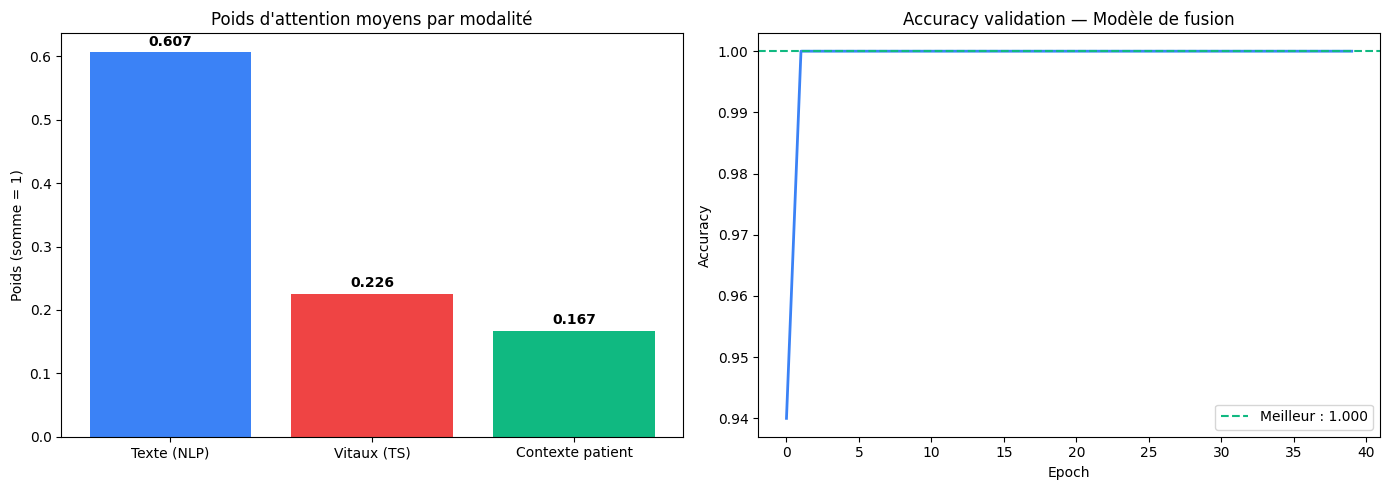


 Poids d'attention appris :
  Texte (NLP)               : 0.607 (60.7%)
  Vitaux (TS)               : 0.226 (22.6%)
  Contexte patient          : 0.167 (16.7%)


In [8]:
# Analyse de ce que le modèle a appris : quelle modalité est la plus importante ?
fusion_model.load_state_dict(
    torch.load("../ml_models/fusion/best_fusion_model.pth", map_location=device)
)
fusion_model.eval()

all_attn_weights = []
with torch.no_grad():
    for x_t, x_v, x_p, _ in test_loader:
        _, attn = fusion_model(x_t.to(device), x_v.to(device), x_p.to(device))
        all_attn_weights.append(attn.cpu().numpy())

attn_avg = np.concatenate(all_attn_weights, axis=0).mean(axis=0)
modalites = ["Texte (NLP)", "Vitaux (TS)", "Contexte patient"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Poids d'attention moyens
axes[0].bar(modalites, attn_avg, color=["#3b82f6", "#ef4444", "#10b981"])
axes[0].set_title("Poids d'attention moyens par modalité")
axes[0].set_ylabel("Poids (somme = 1)")
for i, v in enumerate(attn_avg):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

# Courbe de validation
axes[1].plot(val_accs, color="#3b82f6", linewidth=2)
axes[1].set_title("Accuracy validation — Modèle de fusion")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].axhline(y=best_val_acc, color="#10b981", linestyle="--",
                label=f"Meilleur : {best_val_acc:.3f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/fusion_analysis.png", dpi=150)
plt.show()

print(f"\n Poids d'attention appris :")
for modalite, weight in zip(modalites, attn_avg):
    print(f"  {modalite:25s} : {weight:.3f} ({weight*100:.1f}%)")

In [9]:
os.makedirs("../ml_models/fusion", exist_ok=True)

# Sauvegarde du scaler de fusion
with open("../ml_models/fusion/scaler_vitals.pkl", "wb") as f:
    pickle.dump(scaler_fusion, f)

# Config du modèle de fusion
fusion_config = {
    "text_dim": 4,
    "vitals_dim": 30,
    "patient_dim": 4,
    "hidden_dim": 64,
    "n_classes": 2,
    "dropout": 0.3,
    "attention_weights_avg": attn_avg.tolist(),
    "best_val_accuracy": float(best_val_acc)
}
with open("../ml_models/fusion/model_config.json", "w") as f:
    json.dump(fusion_config, f, indent=2)

print(" Modèle de fusion sauvegardé :")
print("  → ml_models/fusion/best_fusion_model.pth")
print("  → ml_models/fusion/scaler_vitals.pkl")
print("  → ml_models/fusion/model_config.json")

 Modèle de fusion sauvegardé :
  → ml_models/fusion/best_fusion_model.pth
  → ml_models/fusion/scaler_vitals.pkl
  → ml_models/fusion/model_config.json
